### Learning AI Agent 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### import need for creating an basic LLM 


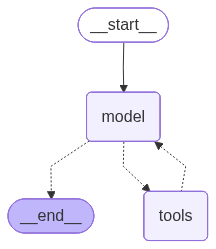

In [2]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq


def calaculate_square_root(number):
    """Calculate the square root of a number."""
    return number ** 0.5
LLM = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0.7,
    api_key=os.getenv("GROQ_API_KEY") 
               )

agent = create_agent(
    model=LLM,
    tools= [calaculate_square_root]
)

agent

In [11]:
response = agent.invoke({"messages" : [{"role":"user" , "content": "What is the square root of 16?"}]})
response["messages"][-1].content

'The square root of 16 is **4.0**.'

In [3]:
models = create_agent(
    model=LLM,
    tools=[]
)

In [22]:
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "why bird feathers are colorful?"}]}
):

    if "model" in chunk:
        print(chunk["model"]["messages"][-1].content, end="", flush=True)

Birds have colorful feathers primarily for reasons related to survival and reproduction. Here's why:

1. **Mate Attraction**: Bright colors and intricate patterns (e.g., peacock tails) signal genetic fitness and health, helping attract mates during courtship.
2. **Camouflage**: Some species blend into their environment (e.g., cryptic colors in forest birds) to avoid predators.
3. **Warning Signals**: Vivid colors (e.g., in poison dart frogs or certain birds) may deter predators by indicating toxicity or unpalatability.
4. **Social Signaling**: Colors can establish dominance, territory, or communication within flocks.

The square root tool isn’t applicable here, but the biological explanations above address the question! 🐦🌈

### Stream

In [4]:


agent_model = ChatGroq( 
    model="qwen/qwen3-32b",
    temperature=0.7,
    api_key=os.getenv("GROQ_API_KEY") 
               )

In [5]:
response=agent_model.invoke("why bird feathers are colorful?")
response.content

"<think>\nOkay, so the user is asking why bird feathers are colorful. Let me start by recalling what I know about bird feathers and their functions. I remember that coloration in animals can serve various purposes like camouflage, attracting mates, or communication. Birds are known for their bright plumage, especially males in many species. \n\nFirst, I should consider the main reasons for coloration. Sexual selection comes to mind. Many birds, like peacocks, have elaborate and colorful feathers to attract females. That's a key point. Then there's also the aspect of camouflage. Some birds have colors that help them blend into their environment to avoid predators. For example, owls might have feathers that make them look like tree bark. \n\nAnother angle is warning coloration, like aposematism. Some birds might have bright colors to signal to predators that they're toxic or unpalatable. Also, there's the possibility of species recognition. Bright colors can help birds identify members o

In [6]:
for chunk in agent_model.stream("why bird feathers are colorful?"):
      print(chunk.text , end="", flush=True)

<think>
Okay, so I need to figure out why bird feathers are colorful. Let me start by recalling what I know. Birds have different colors for various reasons. Maybe it's for attracting mates? I remember that peacocks have those big, colorful tails to show off to peahens. That's probably sexual selection. But are there other reasons?

I think about camouflage too. Some birds might have colors that help them blend into their environment. Like maybe a green feathered bird in the trees. But then why would they be colorful if they need to hide? Unless the color helps with something else. Maybe warning colors, like some animals have bright colors to signal they're poisonous or dangerous. But birds aren't usually poisonous, so maybe that's not the main reason.

Then there's communication. Birds use calls to communicate, but maybe colors also play a role. Like, to signal their species to each other. Or maybe to warn off other birds from their territory. Also, maybe for social interactions withi

In [7]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Get the current weather for a given location."""
    return f"The current weather in {location} is sunny with a high of 25°C."

agent_with_tool  = agent_model.bind_tools([get_weather])
response = agent_with_tool.invoke("What is the current weather in New York?")


### Messages 

In [10]:
from langchain.messages import SystemMessage,HumanMessage

res=agent_model.invoke([SystemMessage(content="You are a helpful assistant.Explain Things in One Line"),
                    HumanMessage(content="why is the sky blue?")])

res.content

"<think>\nOkay, the user is asking why the sky is blue. Let me start by recalling what I know about this. I remember it has something to do with the way light interacts with the atmosphere. The sun emits light that's made up of different colors, each with different wavelengths. Blue light has a shorter wavelength compared to red or yellow. When sunlight enters the Earth's atmosphere, the molecules in the air scatter the light. But why blue specifically?\n\nOh right, Rayleigh scattering! The theory that shorter wavelengths are scattered more effectively. So blue light gets scattered in all directions more than the other colors. That's why when we look up, we see the blue light coming from all the different directions in the sky. But wait, violet light has an even shorter wavelength than blue. Why isn't the sky violet then?\n\nHmm, that's a good point. I think it's because the sun emits less violet light compared to blue. Also, our eyes are more sensitive to blue and less to violet. Plus